In [1]:
import csv
from datetime import datetime
import json


LIMITE_SUSPEITO = 10000.00
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"


In [2]:
def gerar_csv():

  dados = [
    [1, "2026-01-05", "CLI001", "credito", 3500.00, "Salario Janeiro", "salario"],
    [2, "2026-01-08", "CLI002", "debito", 250.75, "Supermercado", "compra"],
    [21, "2026-01-20", "CLI001", "debito", "abc", "Valor Invalido", "compra"],

    [3, "2026-01-12", "CLI003", "debito", 120.00, "Internet", "conta"],
    [4, "2026-01-18", "CLI001", "credito", 500.00, "Freelance", "servico"],
    [5, "2026-01-25", "CLI004", "debito", 89.90, "Streaming", "assinatura"],

    [6, "2026-02-03", "CLI002", "credito", 4200.00, "Salario Fevereiro", "salario"],
    [22, "2026-02-11", "", "debito", 300.00, "Cliente Vazio", "transferencia"],
    [7, "2026-02-07", "CLI005", "debito", 560.00, "Aluguel", "moradia"],

    [8, "2026-02-14", "CLI003", "credito", 15000.00, "Transferencia Recebida", "transferencia"],
    [9, "2026-02-20", "CLI001", "debito", 320.40, "Conta de Luz", "conta"],
    [10, "2026-02-28", "CLI004", "debito", 145.00, "Farmacia", "saude"],

    ["XYZ", "2026-03-08", "CLI005", "credito", 1000.00, "ID Invalido", "servico"],
    [11, "2026-03-01", "CLI001", "credito", 3500.00, "Salario Marco", "salario"],
    [12, "2026-03-09", "CLI002", "debito", 210.50, "Combustivel", "transporte"],

    [13, "2026-03-15", "CLI006", "credito", 12500.00, "Bonus Anual", "bonus"],
    [14, "2026-03-22", "CLI005", "debito", 980.00, "Moveis", "casa"],
    [24, "15/04/2026", "CLI007", "credito", 2500.00, "Data Invalida", "salario"],

    [15, "2026-03-30", "CLI003", "debito", 75.90, "Lanche", "alimentacao"],
    [16, "2026-04-05", "CLI007", "credito", 18000.00, "Investimento Resgatado", "investimento"],
    [17, "2026-04-10", "CLI001", "debito", 450.00, "Curso Online", "educacao"],

    [25, "2026-04-25", "CLI003", "pix", 500.00, "Tipo Invalido", "transferencia"],
    [18, "2026-04-18", "CLI004", "credito", 2800.00, "Venda Equipamento", "venda"],
    [19, "2026-04-22", "CLI006", "debito", 670.30, "Seguro", "seguro"],
    [20, "2026-04-28", "CLI002", "debito", 199.90, "Academia", "saude"]
  ]

  with open("transacoes.csv", "w", newline="", encoding="utf-8") as arquivo:
      escritor = csv.writer(arquivo)

      escritor.writerow([
          "id",
          "data",
          "cliente_id",
          "tipo",
          "valor",
          "descricao",
          "categoria"
      ])

      escritor.writerows(dados)

  print("Arquivo transacoes.csv criado com sucesso!")
  print(f"Total de registros: {len(dados)}")

gerar_csv()

Arquivo transacoes.csv criado com sucesso!
Total de registros: 25


In [3]:
def validar_transacao(linha):
  try:
    #ID
    if not linha["id"].strip():
      return None

    id_transacao = int(linha["id"])

    # Cliente
    cliente_id = linha["cliente_id"].strip()

    if not cliente_id:
      return None

    # Data
    data = datetime.strptime(linha["data"].strip(), "%Y-%m-%d")

    # Tipo
    tipo = linha["tipo"].strip().lower()

    if tipo not in ["credito", "debito"]:
      return None

    # Valor
    valor = float(linha["valor"])

    if valor <= 0:
      return None


    # Retorna registro limpo
    return {
      "id": id_transacao,
      "data": data,
      "cliente_id": cliente_id,
      "tipo": tipo,
      "valor": valor,
      "descricao": linha["descricao"].strip(),
      "categoria": linha["categoria"].strip()
    }

  except ValueError:
    return None

  except KeyError:
    return None

In [4]:
def ler_transacoes():
  transacoes_validas = []
  total_lidas = 0
  total_invalidas = 0

  try:
    with open(ARQUIVO_CSV, "r", encoding="utf-8") as arquivo:
      leitor = csv.DictReader(arquivo)

      for linha in leitor:
        total_lidas += 1

        transacao = validar_transacao(linha)

        if transacao:
          transacoes_validas.append(transacao)
        else:
          total_invalidas += 1

  except FileNotFoundError:
    print(f"Arquivo '{ARQUIVO_CSV}' não encontrado.")
    return [], 0, 0

  return transacoes_validas, total_lidas, total_invalidas


In [5]:
def agrupar_por_mes(transacoes):
    resumo_mensal = {}

    for transacao in transacoes:
        mes = transacao["data"].strftime("%Y-%m")

        if mes not in resumo_mensal:
            resumo_mensal[mes] = []

        resumo_mensal[mes].append(transacao)

    return resumo_mensal

In [6]:
def calcular_metricas_mes(transacoes_mes):
    quantidade = len(transacoes_mes)

    total_credito = 0
    total_debito = 0

    valores = []

    for transacao in transacoes_mes:
      valor = transacao["valor"]
      valores.append(valor)

      if transacao["tipo"] == "credito":
        total_credito += valor
      else:
        total_debito += valor

    saldo = total_credito - total_debito
    media = sum(valores) / quantidade
    maior_valor = max(valores)
    menor_valor = min(valores)


    return {
        "quantidade": quantidade,
        "total_credito": total_credito,
        "total_debito": total_debito,
        "saldo": saldo,
        "media": media,
        "maior_valor": maior_valor,
        "menor_valor": menor_valor
    }

In [7]:
def identificar_suspeitas(transacoes):
    suspeitas = []

    for transacao in transacoes:

        if transacao["valor"] > LIMITE_SUSPEITO:
            suspeitas.append(transacao)

    return suspeitas

In [8]:
def obter_periodo_analisado(transacoes):

    datas = []

    for transacao in transacoes:
        datas.append(transacao["data"])

    data_mais_antiga = min(datas)

    data_mais_recente = max(datas)

    dias_analisados = (
        data_mais_recente -
        data_mais_antiga
    ).days

    return {
        "data_mais_antiga": data_mais_antiga,
        "data_mais_recente": data_mais_recente,
        "dias_analisados": dias_analisados
    }

In [9]:
def gerar_relatorio(transacoes):
   transacoes_por_mes = agrupar_por_mes(transacoes)

   resumo_mensal = {}


   for mes, lista_transacoes in transacoes_por_mes.items():

      resumo_mensal[mes] = calcular_metricas_mes(
            lista_transacoes
      )

   suspeitas = identificar_suspeitas(
        transacoes
   )

   periodo = obter_periodo_analisado(
      transacoes
   )

   return {
        "resumo_mensal": resumo_mensal,
        "suspeitas": suspeitas,
        "periodo": periodo
   }

In [10]:
def formatar_moeda(valor):
  return (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

In [11]:
def resumo_geral(periodo, total_valida, total_invalidas):

  print("\n===== RESUMO GERAL =====")

  print(
    f"\nPeríodo analisado:"
  )

  print(
    f"\n{periodo['data_mais_antiga'].strftime('%Y-%m-%d')} "
    f"até "
    f"{periodo['data_mais_recente'].strftime('%Y-%m-%d')}"
  )

  print(
    f"\nDias analisados: "
    f"{periodo['dias_analisados']}"
  )

  print(
    f"\nTotal de linhas lidas: "
    f"{total_valida + total_invalidas}"
  )

  print(
    f"\nLinhas válidas: "
    f"{total_valida}"
  )

  print(
    f"Linhas inválidas: "
    f"{total_invalidas}"
  )


In [12]:
def relatorio_mensal(relatorio):
  print("\n===== RELATÓRIO MENSAL =====")

  for mes, dados in relatorio["resumo_mensal"].items():
    print(f"\nMês: {mes}")

    print(
      f"  Transações: "
      f"{dados['quantidade']}"
    )

    print(
      f"  Total crédito: "
      f"{formatar_moeda(dados['total_credito'])}"
    )

    print(
      f"  Total débito: "
      f"{formatar_moeda(dados['total_debito'])}"
    )

    print(
      f"  Saldo: "
      f"{formatar_moeda(dados['saldo'])}"
    )

    print(
      f"  Média: "
      f"{formatar_moeda(dados['media'])}"
    )

    print(
      f"  Maior valor: "
      f"{formatar_moeda(dados['maior_valor'])}"
    )

    print(
      f"  Menor valor: "
      f"{formatar_moeda(dados['menor_valor'])}"
    )


In [13]:
def transacoes_suspeitas(relatorio):
  print("\n===== TRANSAÇÕES SUSPEITAS =====")

  suspeitas = relatorio["suspeitas"]

  if not suspeitas:
    print(
        "Nenhuma transação suspeita encontrada."
    )
  else:
    for transacao in suspeitas:

      print(
        f"\nID: {transacao['id']} | "
        f"Cliente: {transacao['cliente_id']} | "
        f"Data: {transacao['data'].strftime('%Y-%m-%d')} | "
        f"Valor: {formatar_moeda(transacao['valor'])}"
      )

In [14]:
def exibir_relatorio(relatorio, total_lida, total_invalidas):
  periodo = relatorio["periodo"]

  resumo_geral(periodo, total_lida, total_invalidas)

  relatorio_mensal(relatorio)

  transacoes_suspeitas(relatorio)


In [15]:
def salvar_json(relatorio, total_validas, total_invalidas):
    periodo = relatorio["periodo"]

    suspeitas_json = []

    for transacao in relatorio["suspeitas"]:

      suspeitas_json.append({
        "id": transacao["id"],
        "cliente_id": transacao["cliente_id"],
        "data": transacao["data"].strftime("%Y-%m-%d"),
        "valor": transacao["valor"]
      })

    dados_json = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),

        "total_transacoes_validas": total_validas,

        "total_transacoes_invalidas": total_invalidas,

        "periodo": {
            "data_mais_antiga": periodo["data_mais_antiga"].strftime("%Y-%m-%d"),
            "data_mais_recente": periodo["data_mais_recente"].strftime("%Y-%m-%d"),
            "dias_analisados": periodo["dias_analisados"]
        },

        "resumo_mensal": relatorio['resumo_mensal'],

        "transacoes_suspeitas": suspeitas_json
    }

    with open(
        "relatorio.json",
        "w",
        encoding="utf-8"
    ) as arquivo:

      json.dump(
            dados_json,
            arquivo,
            ensure_ascii=False,
            indent=2
        )

    print("\n================================")
    print("Arquivo relatorio.json gerado com sucesso!")

In [16]:
transacoes, total_lida, total_invalidas = ler_transacoes()

relatorio = gerar_relatorio(transacoes)

exibir_relatorio(relatorio, len(transacoes), total_invalidas)

salvar_json(relatorio, len(transacoes), total_invalidas)



===== RESUMO GERAL =====

Período analisado:

2026-01-05 até 2026-04-28

Dias analisados: 113

Total de linhas lidas: 25

Linhas válidas: 20
Linhas inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 4.000,00
  Total débito: R$ 460,65
  Saldo: R$ 3.539,35
  Média: R$ 892,13
  Maior valor: R$ 3.500,00
  Menor valor: R$ 89,90

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 19.200,00
  Total débito: R$ 1.025,40
  Saldo: R$ 18.174,60
  Média: R$ 4.045,08
  Maior valor: R$ 15.000,00
  Menor valor: R$ 145,00

Mês: 2026-03
  Transações: 5
  Total crédito: R$ 16.000,00
  Total débito: R$ 1.266,40
  Saldo: R$ 14.733,60
  Média: R$ 3.453,28
  Maior valor: R$ 12.500,00
  Menor valor: R$ 75,90

Mês: 2026-04
  Transações: 5
  Total crédito: R$ 20.800,00
  Total débito: R$ 1.320,20
  Saldo: R$ 19.479,80
  Média: R$ 4.424,04
  Maior valor: R$ 18.000,00
  Menor valor: R$ 199,90

===== TRANSAÇÕES SUSPEITAS =====

ID: 8 | Cliente: CLI003 | Data: 2026-02-14 | V

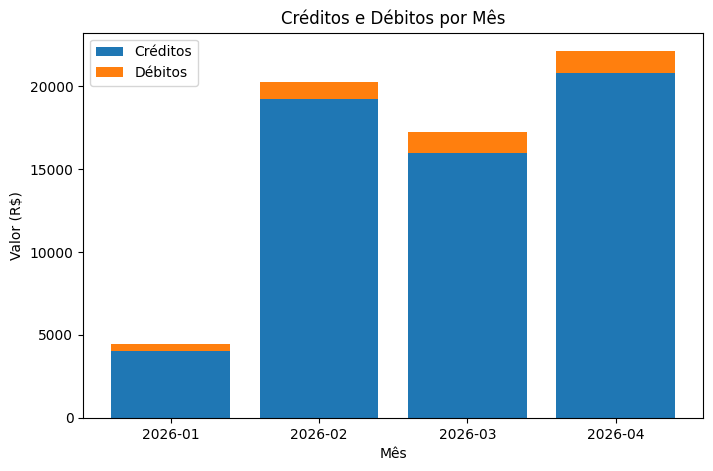

In [18]:
import matplotlib.pyplot as plt

meses = []
creditos = []
debitos = []

for mes, dados in relatorio["resumo_mensal"].items():
    meses.append(mes)
    creditos.append(dados["total_credito"])
    debitos.append(dados["total_debito"])

plt.figure(figsize=(8, 5))

plt.bar(
    meses,
    creditos,
    label="Créditos"
)

plt.bar(
    meses,
    debitos,
    bottom=creditos,
    label="Débitos"
)

plt.title("Créditos e Débitos por Mês")
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.legend()

plt.savefig("grafico.png")
plt.show()

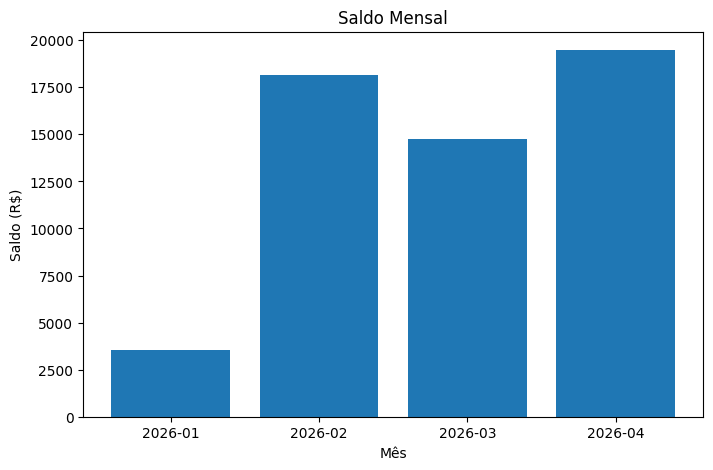

In [17]:
import matplotlib.pyplot as plt

meses = []
saldos = []

for mes, dados in relatorio["resumo_mensal"].items():
    meses.append(mes)
    saldos.append(dados["saldo"])

plt.figure(figsize=(8, 5))

plt.bar(meses, saldos)

plt.title("Saldo Mensal")

plt.xlabel("Mês")

plt.ylabel("Saldo (R$)")

#plt.savefig("grafico.png")

plt.show()

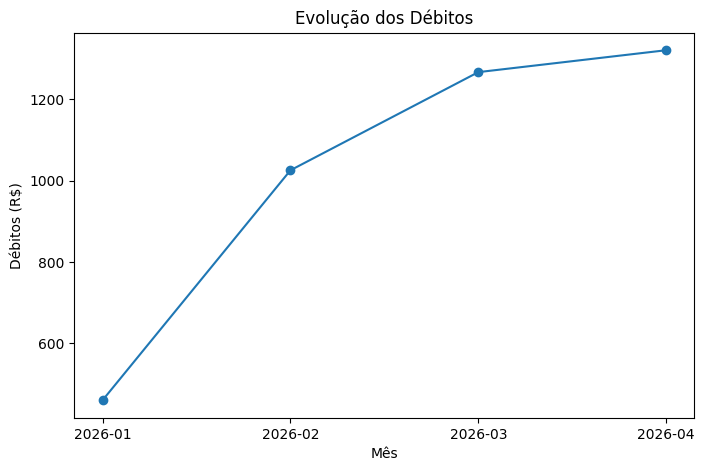

In [19]:
import matplotlib.pyplot as plt

meses = []
debitos = []

for mes, dados in relatorio["resumo_mensal"].items():
    meses.append(mes)
    debitos.append(dados["total_debito"])

plt.figure(figsize=(8, 5))
plt.plot(meses, debitos, marker="o")

plt.title("Evolução dos Débitos")
plt.xlabel("Mês")
plt.ylabel("Débitos (R$)")

#plt.savefig("grafico_debitos.png")
plt.show()